# Exploratory Data Analysis (EDA) and Data Cleaning (2023 - 2034)
Goal: Clean NBA shot data, define clutch scenarios, and prepare for ML modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clutch_df = pd.read_csv("../data/raw/shot_data.2021.csv")

In [ ]:
# Basic Dataset Information
print("Dataset Shape:", clutch_df.shape)
print("Number of Features:", clutch_df.shape[1])
print("Number of Instances:", clutch_df.shape[0])

Dataset Shape: (34221, 24)

Columns:
Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM'],
      dtype='str')


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,22300015,7,2544,LeBron James,1610612747,Los Angeles Lakers,1,11,40,...,Center(C),16-24 ft.,17,-47,172,1,0,20231110,PHX,LAL
1,Shot Chart Detail,22300015,11,2544,LeBron James,1610612747,Los Angeles Lakers,1,11,12,...,Center(C),Less Than 8 ft.,0,2,5,1,1,20231110,PHX,LAL
2,Shot Chart Detail,22300015,20,2544,LeBron James,1610612747,Los Angeles Lakers,1,10,1,...,Left Side(L),8-16 ft.,12,-119,32,1,0,20231110,PHX,LAL
3,Shot Chart Detail,22300015,36,2544,LeBron James,1610612747,Los Angeles Lakers,1,9,0,...,Center(C),Less Than 8 ft.,0,1,8,1,1,20231110,PHX,LAL
4,Shot Chart Detail,22300015,72,2544,LeBron James,1610612747,Los Angeles Lakers,1,5,18,...,Left Side(L),8-16 ft.,12,-82,89,1,0,20231110,PHX,LAL


In [ ]:
# Summary of Data Types
clutch_df.info()

In [ ]:
# Missing Values Analysis: means to identify any columns with missing data and understand the extent of "missingness"
missing_values = clutch_df.isnull().sum()
missing_percent = (missing_values / len(clutch_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

Series([], dtype: int64)


In [ ]:
# Drop rows with missing values in critical columns
df = clutch_df.dropna(subset=[
    'SHOT_DISTANCE',
    'SHOT_MADE_FLAG',
    'PERIOD',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'])

In [ ]:
# Print the shape of the cleaned dataset
print("Cleaned Shape:", df.shape)

Cleaned Shape: (34221, 24)


In [ ]:
# Time Remaining Calculation: Create a new column, combines minutes and seconds remaining into a single value representing total seconds remaining in the period
df['TIME_REMAINING'] = (
    df['MINUTES_REMAINING'] * 60 +
    df['SECONDS_REMAINING']
)

In [ ]:
# Define clutch situations: 4th quarter or overtime with 2 minutes or less remaining
df['CLUTCH'] = (
    (df['PERIOD'] >= 4) &
    (df['TIME_REMAINING'] <= 120)
)

In [ ]:
# Filter the dataset to include only clutch situations for further analysis
clutch_df = df[df['CLUTCH'] == True]

In [ ]:
# Print the shape of the clutch dataset and the distribution of players to understand how many clutch shots we have and which players stand out
print("Clutch Dataset Shape:", clutch_df.shape)
print(clutch_df['PLAYER_NAME'].value_counts())

Clutch Dataset Shape: (1407, 26)
PLAYER_NAME
Stephen Curry              105
De'Aaron Fox               101
Anthony Edwards             85
Damian Lillard              69
Shai Gilgeous-Alexander     65
Jayson Tatum                62
Trae Young                  60
Victor Wembanyama           59
Nikola Jokić                58
Kevin Durant                55
Giannis Antetokounmpo       52
Donovan Mitchell            51
Pascal Siakam               50
LeBron James                49
Kawhi Leonard               45
Devin Booker                43
Luka Dončić                 41
Jordan Poole                41
Klay Thompson               38
Jaylen Brown                36
Brandon Ingram              35
Joel Embiid                 34
Bam Adebayo                 34
Anthony Davis               32
Karl-Anthony Towns          30
Aaron Gordon                29
Zion Williamson             28
Ja Morant                   11
Rudy Gobert                  8
Otto Porter Jr.              1
Name: count, dtype: int64

In [ ]:
# Save the processed clutch dataset to a new CSV file
clutch_df.to_csv("../data/processed/clutch_shot_data.2023.csv", index=False)

In [ ]:
# Analyze shooting performance by player in clutch situations
player_fg = clutch_df.groupby('PLAYER_NAME')['SHOT_MADE_FLAG'].mean().sort_values(ascending=False)

print(player_fg)

PLAYER_NAME
Otto Porter Jr.            1.000000
Ja Morant                  0.636364
Rudy Gobert                0.625000
Shai Gilgeous-Alexander    0.584615
Giannis Antetokounmpo      0.576923
Nikola Jokić               0.568966
Pascal Siakam              0.560000
Aaron Gordon               0.551724
Zion Williamson            0.535714
Luka Dončić                0.512195
Devin Booker               0.511628
LeBron James               0.489796
Kawhi Leonard              0.488889
Stephen Curry              0.476190
Jayson Tatum               0.451613
Joel Embiid                0.441176
Bam Adebayo                0.441176
Victor Wembanyama          0.440678
Anthony Edwards            0.435294
Karl-Anthony Towns         0.433333
Brandon Ingram             0.428571
Donovan Mitchell           0.411765
Anthony Davis              0.406250
Kevin Durant               0.400000
De'Aaron Fox               0.396040
Damian Lillard             0.391304
Trae Young                 0.366667
Jaylen Brown    

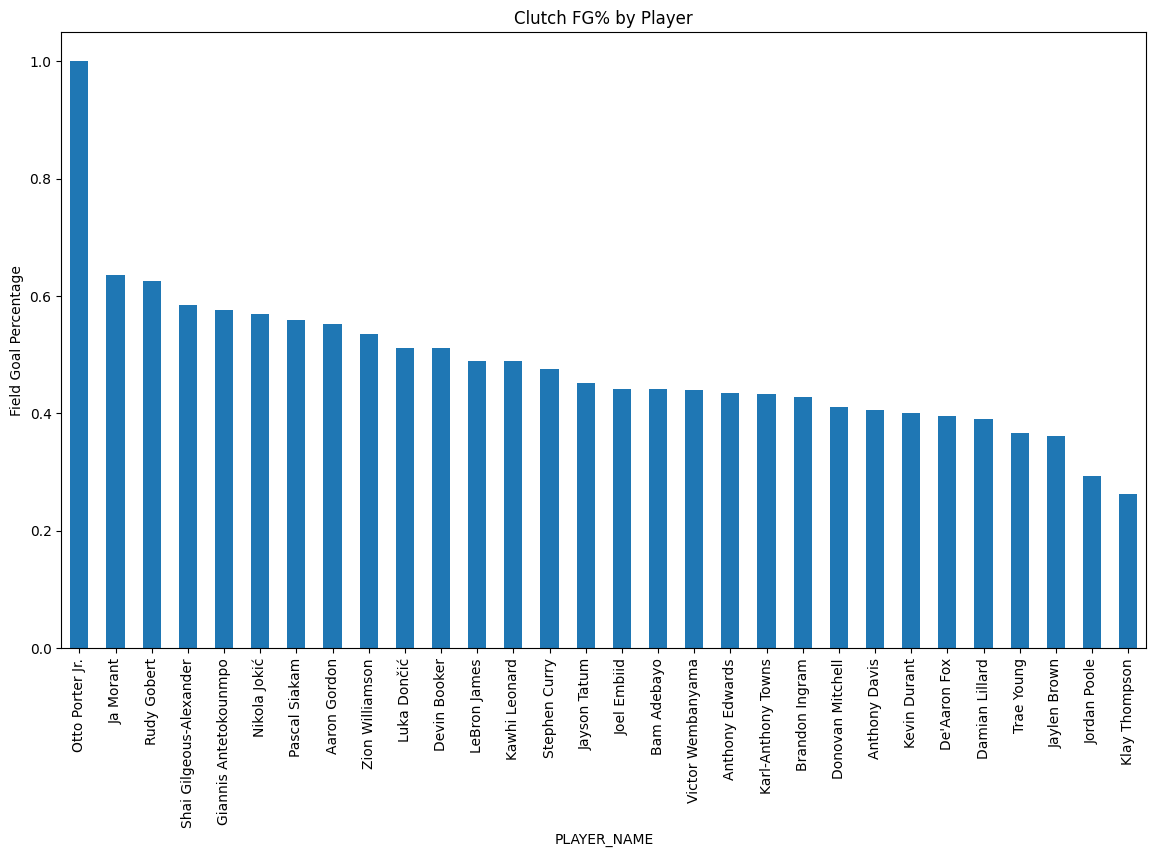

In [ ]:
# Visualize the clutch shooting performance of players using a bar chart
plt.figure(figsize=(14,8))
player_fg.plot(kind='bar')
plt.title("Clutch FG% by Player")
plt.ylabel("Field Goal Percentage")
plt.show()

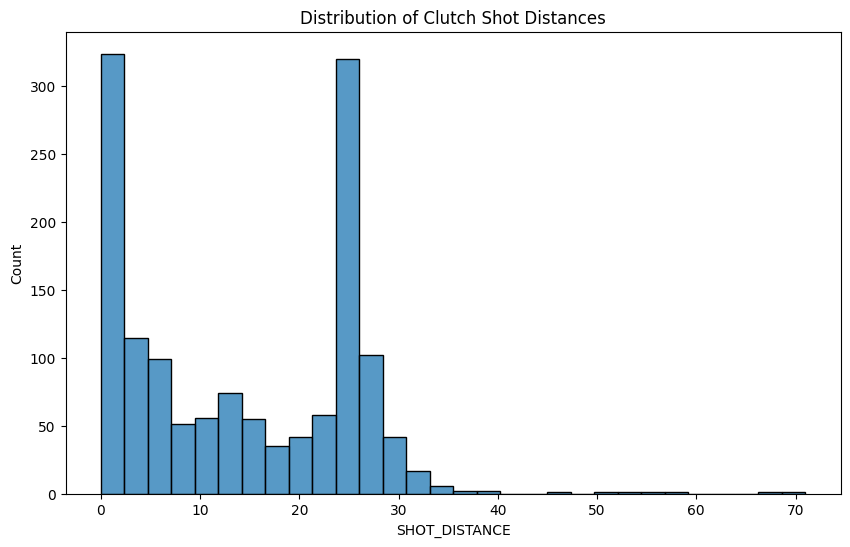

In [ ]:
# Analyze shot distance distribution in clutch situations, histogram shows shot distance vs number of times shot was taken at said distance
plt.figure(figsize=(10,6))
sns.histplot(clutch_df['SHOT_DISTANCE'], bins=30)
plt.title("Distribution of Clutch Shot Distances")
plt.show()

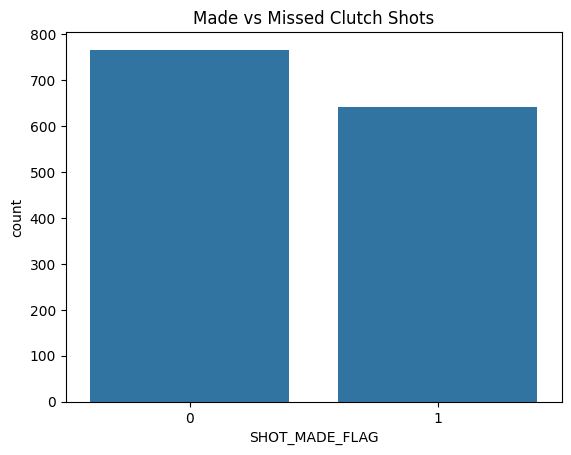

In [ ]:
# Visualize the distribution of made vs missed clutch shots
sns.countplot(x='SHOT_MADE_FLAG', data=clutch_df)
plt.title("Made vs Missed Clutch Shots")
plt.show()

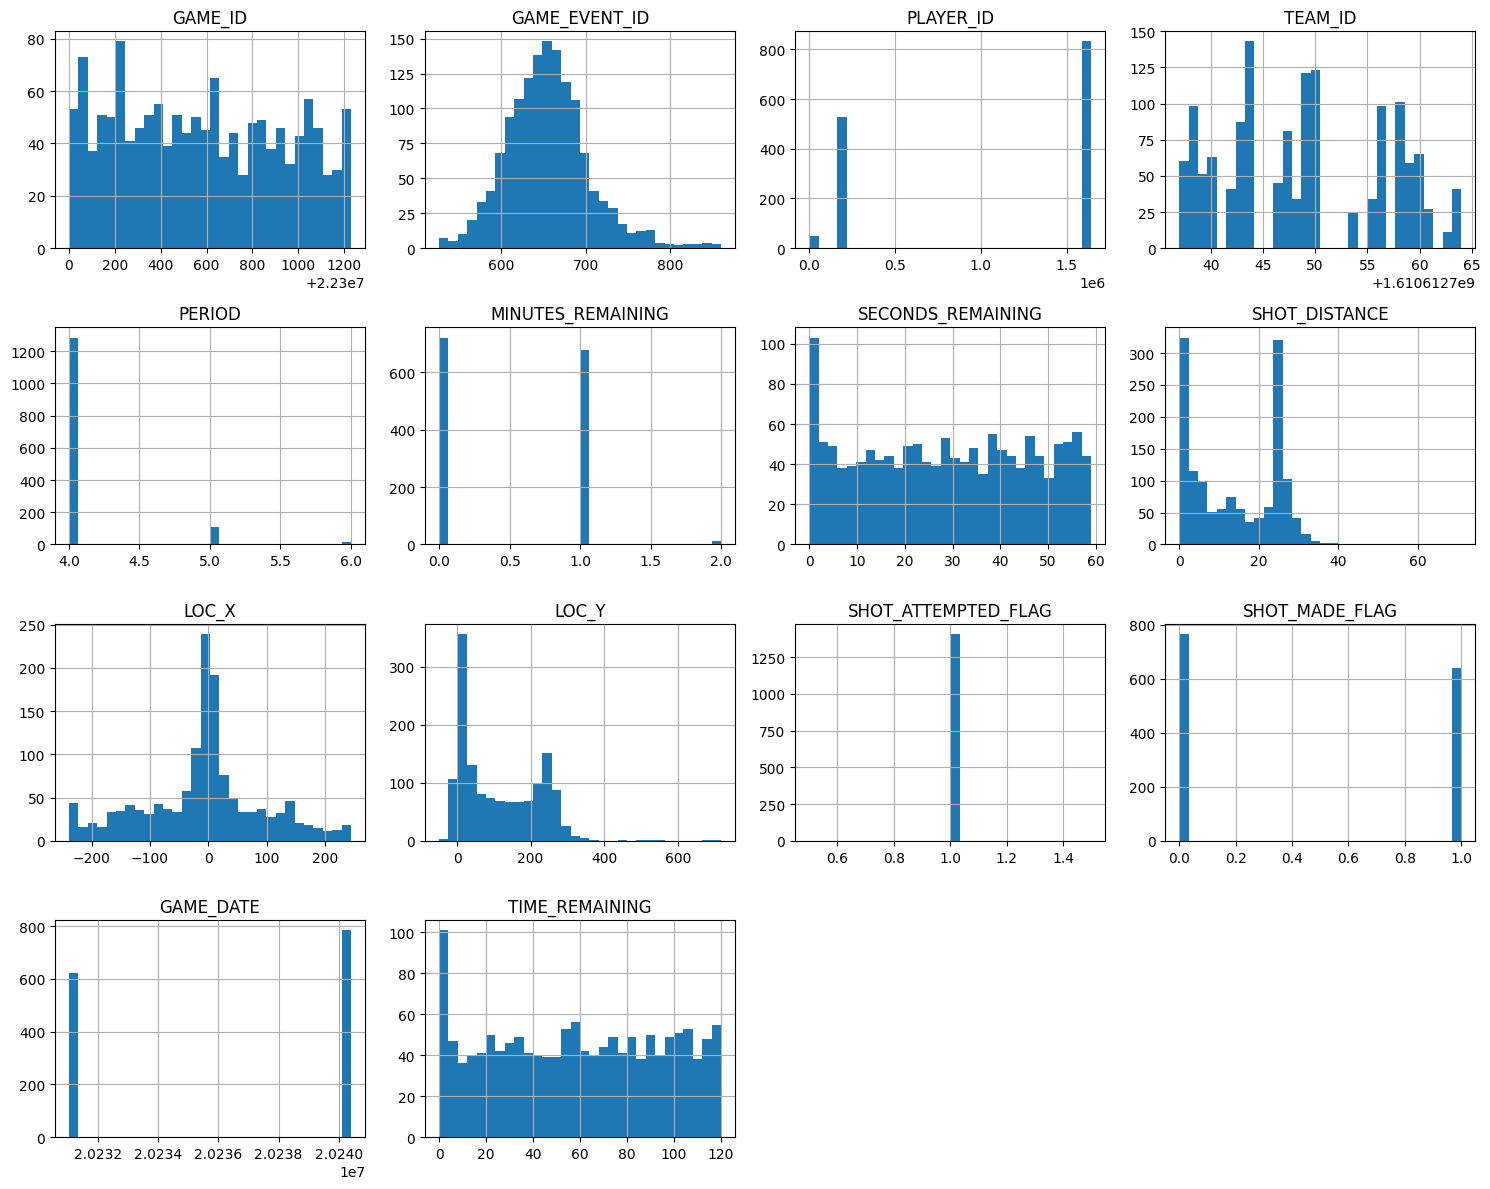

In [ ]:
# Various graphs for each numeric column to find any odd distributions or outliers that may need to be addressed in the modeling phase
numeric_cols = clutch_df.select_dtypes(include=['int64', 'float64']).columns

clutch_df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

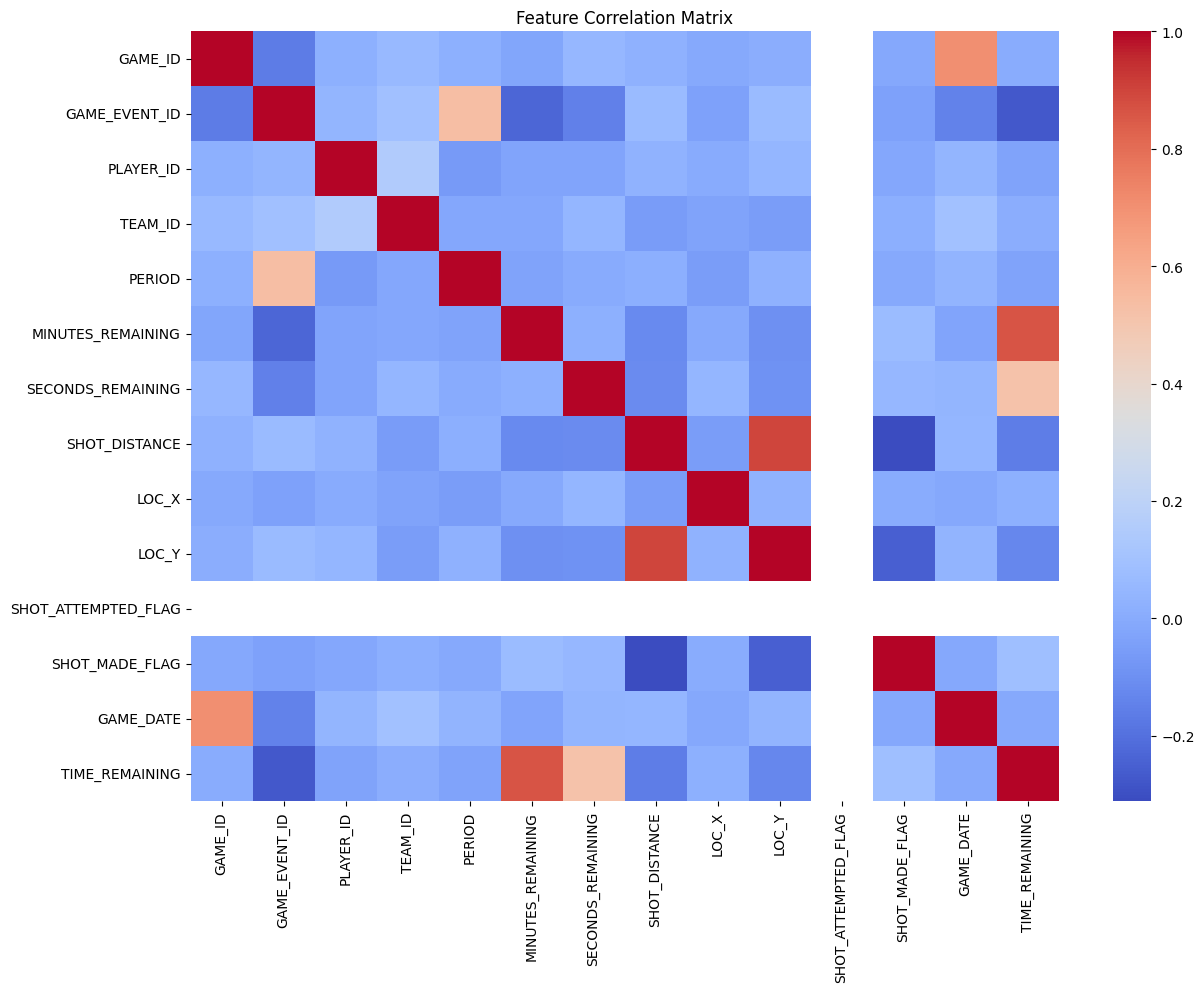

In [18]:
# Correlation Matrix to calculate the correlation between numeric features in the clutch dataset, to identify which features are strongly correlated with each other and with the target variable (SHOT_MADE_FLAG), in order to inform feature selection and engineering for modeling
corr_matrix = clutch_df[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [19]:
# Calculate and print the variance of each numeric feature to identify which features have low variance and may not contribute much to the model
# Low variance = may not be useful for prediction and could potentially be removed to simplify the model
# High variance = may contain more information and be more useful for prediction
feature_variance = clutch_df[numeric_cols].var()
print(feature_variance.sort_values())

SHOT_ATTEMPTED_FLAG    0.000000e+00
PERIOD                 1.164074e-01
SHOT_MADE_FLAG         2.482032e-01
MINUTES_REMAINING      2.658097e-01
TEAM_ID                5.980386e+01
SHOT_DISTANCE          1.248352e+02
SECONDS_REMAINING      3.269575e+02
TIME_REMAINING         1.306415e+03
GAME_EVENT_ID          2.416261e+03
LOC_X                  1.026094e+04
LOC_Y                  1.109303e+04
GAME_ID                1.270547e+05
GAME_DATE              2.038455e+07
PLAYER_ID              5.053240e+11
dtype: float64


In [20]:
# Standardize numeric features to have mean = 0 and variance = 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clutch_df[numeric_cols])

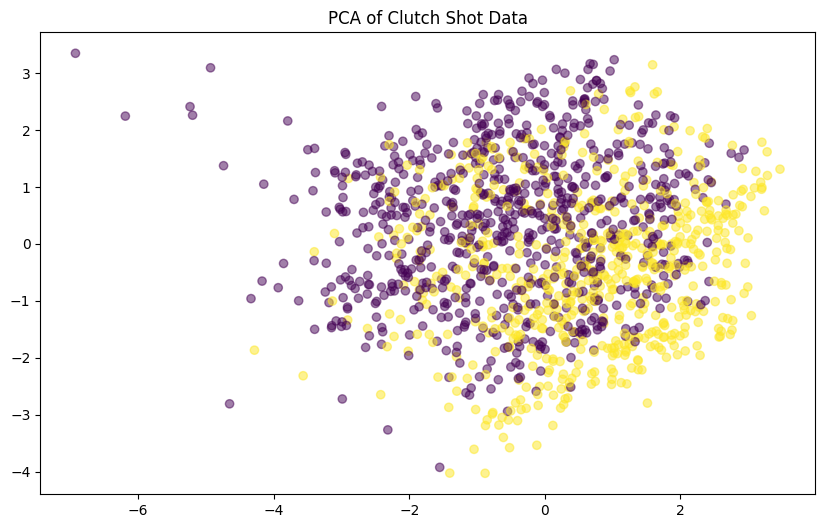

In [21]:
# Perform PCA to reduce dimensionality and visualize the data in 2D, allowing us to see if there are any natural clusters or separations in the data based on the clutch shot features
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(10,6))
plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=clutch_df['SHOT_MADE_FLAG'],
    alpha=0.5
)
plt.title("PCA of Clutch Shot Data")
plt.show()

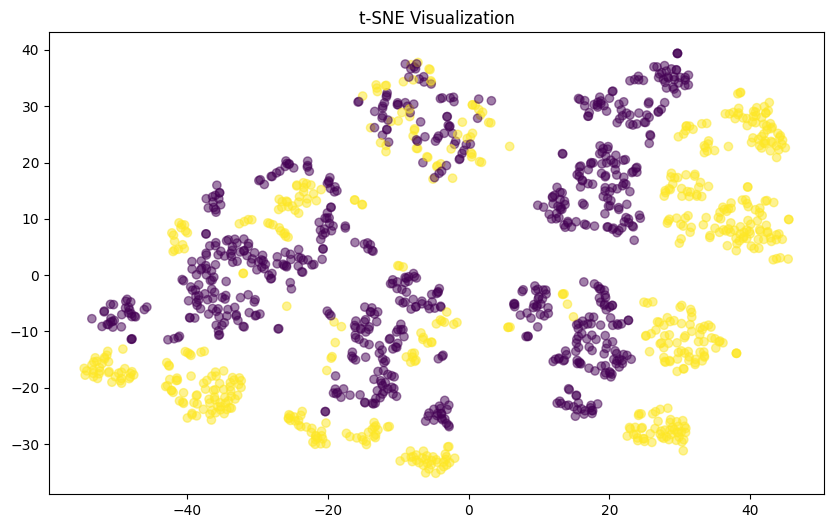

In [22]:
# Perform t-SNE for a more complex, non-linear dimensionality reduction to visualize potential clusters in the clutch shot data, which may not be captured by PCA
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(scaled_features[:5000])  # sample for speed, 

plt.figure(figsize=(10,6))
plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=clutch_df['SHOT_MADE_FLAG'][:5000],
    alpha=0.5
)
plt.title("t-SNE Visualization")
plt.show()